# CS402 Data Science Semester Project
## Predictive Modeling for Retail Inventory Demand: A Time-Series Forecasting Approach
**Team Members:** Abdul wasay sial, Muhammad Faseeh Anjum, Muhammad Ahsan Ali

**Objective:**
To design and implement a complete Data Science pipeline capable of forecasting daily sales turnover using the Rossmann Store Sales dataset. This project emphasizes rigorous data preparation, temporal feature engineering, and the comparative analysis of statistical and tree-based machine learning models using Expanding Window Cross-Validation to prevent temporal data leakage.

In [1]:
# 1. Environment Setup & Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
import os

# Suppress warnings for cleaner output in the final report
warnings.filterwarnings('ignore')

# Industrial standard visualization settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
print("Environment configured successfully.")

Environment configured successfully.


## 1. Data Ingestion & Relational Merging
The raw dataset consists of transactional logs (`train.csv`) and static metadata (`store.csv`). To create a comprehensive analytical view, we perform a relational left join on the `Store` ID, mirroring standard database synchronization practices.

In [2]:
# 2. Data Loading and Merging
def load_and_merge_data(train_path='../data/train.csv', store_path='../data/store.csv'):
    print("Loading raw datasets...")
    # Parsing dates immediately is crucial for time-series operations
    train_df = pd.read_csv(train_path, parse_dates=['Date'], low_memory=False)
    store_df = pd.read_csv(store_path)
    
    print("Merging transactional data with store metadata...")
    df = pd.merge(train_df, store_df, on='Store', how='left')
    
    # CRITICAL: Sort chronologically to prevent future data leakage during training
    df = df.sort_values(by=['Date', 'Store']).reset_index(drop=True)
    return df

# Execute the load and merge
raw_df = load_and_merge_data()
print(f"Merged Dataset Shape: {raw_df.shape}")

Loading raw datasets...
Merging transactional data with store metadata...
Merged Dataset Shape: (1017209, 18)


## 2. Data Preprocessing & Temporal Feature Engineering
Real-world data is inherently messy. In this phase, we:
1.  **Impute Missing Values:** Handle missing competitor data logically rather than using global means.
2.  **Extract Temporal Features:** Decompose the `Date` object into granular numerical features ($Year$, $Month$, $DayOfWeek$) so algorithms can recognize seasonality.
3.  **Target Encoding:** Convert categorical variables into numerical weights based on expected sales volume.

In [ ]:
# 3. Preprocessing Logic
def preprocess_pipeline(df):
    print("Starting Data Preprocessing Pipeline...")
    data = df.copy()
    
    # A. Handle Missing Values Logically
    max_distance = data['CompetitionDistance'].max() * 2
    data['CompetitionDistance'].fillna(max_distance, inplace=True)
    
    promo_num_cols = ['Promo2SinceWeek', 'Promo2SinceYear',
                      'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']
    for col in promo_num_cols:
        if col in data.columns:
            data[col].fillna(0, inplace=True)
            
    if 'PromoInterval' in data.columns:
        data['PromoInterval'].fillna('None', inplace=True)
        
    # B. Extract Temporal Features
    data['Year'] = data['Date'].dt.year
    data['Month'] = data['Date'].dt.month
    data['DayOfWeek'] = data['Date'].dt.dayofweek
    data['IsWeekend'] = data['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
    
    # C. Filter Data (Only keep days where the store was actually open and had sales)
    data = data[(data['Open'] != 0) & (data['Sales'] > 0)]
    
    # D. Categorical Encoding (StoreType and Assortment mapping)
    store_type_map = {'a': 1, 'b': 2, 'c': 3, 'd': 4}
    assortment_map = {'a': 1, 'b': 2, 'c': 3}
    data['StoreType'] = data['StoreType'].map(store_type_map)
    data['Assortment'] = data['Assortment'].map(assortment_map)
    
    # E. Lag Features (Crucial for Time-Series forecasting)
    print("Generating 7-day and 30-day historical lag features...")
    # FIXED: Sorting purely by Store and the exact Date to maintain true chronological order
    data = data.sort_values(by=['Store', 'Date']) 
    
    data['Sales_Lag_7'] = data.groupby('Store')['Sales'].shift(7)
    data['Sales_Lag_30'] = data.groupby('Store')['Sales'].shift(30)
    data['Sales_Lag_7'].fillna(0, inplace=True)
    data['Sales_Lag_30'].fillna(0, inplace=True)
    
    # F. Final NaN cleanup
    data.replace([np.inf, -np.inf], np.nan, inplace=True)
    numeric_cols = data.select_dtypes(include=['number']).columns
    data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
    data.dropna(inplace=True)
    
    # Drop non-numerical columns no longer needed for ML matrices
    cols_to_drop = ['Date', 'Customers', 'StateHoliday', 'PromoInterval', 'Open']
    data.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    
    print(f"Pipeline Complete. Final clean shape: {data.shape}")
    return data

clean_df = preprocess_pipeline(raw_df)

def advanced_preprocessing(df):
    print("Applying Advanced Preprocessing (Outliers & Scaling)...")
    data = df.copy()
    
    Q1 = data['Sales'].quantile(0.25)
    Q3 = data['Sales'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    data['Sales'] = np.where(data['Sales'] > upper_bound, upper_bound, data['Sales'])
    print(f"Capped extreme sales outliers at turnover value: {upper_bound:.2f}")
    
    # B. Feature Scaling
    scaler = StandardScaler()
    num_cols = ['CompetitionDistance', 'Sales_Lag_7', 'Sales_Lag_30']
    data[num_cols] = scaler.fit_transform(data[num_cols])
    
    print("Advanced Preprocessing Complete.")
    return data

scaled_df = advanced_preprocessing(clean_df)
scaled_df.to_csv('cleaned_rossmann_data.csv', index=False)
print("Cleaned dataset successfully saved as 'cleaned_rossmann_data.csv' in the project folder.")


Starting Data Preprocessing Pipeline...
Generating 7-day and 30-day historical lag features...
Pipeline Complete. Final clean shape: (421046, 18)
Applying Advanced Preprocessing (Outliers & Scaling)...
Capped extreme sales outliers at turnover value: 12779.50
Advanced Preprocessing Complete.
Cleaned dataset successfully saved as 'cleaned_rossmann_data.csv' in the project folder.


## 3. Comprehensive Exploratory Data Analysis (EDA)
Visual validation of underlying business logic across 8 distinct dimensions, including target variable distribution, the impact of promotional campaigns, feature correlations, and seasonality.

In [ ]:
# 3. Comprehensive Exploratory Data Analysis (EDA)
def generate_comprehensive_eda(df):
    print("Generating 8-Chart EDA Suite...")
    
    # Create directory if it doesn't exist
    if not os.path.exists('visualizations'):
        os.makedirs('visualizations')
        
    plt.figure()
    sns.histplot(df['Sales'], bins=50, kde=True, color='teal')
    plt.title('1. Distribution of Daily Sales (Outliers Capped)')
    plt.savefig('visualizations/1_sales_dist.png', bbox_inches='tight')
    plt.close()
    
    plt.figure()
    sns.boxplot(x='Promo', y='Sales', data=df, palette='Set2')
    plt.title('2. Sales Comparison: Active Promotion vs. None')
    plt.savefig('visualizations/2_promo_impact.png', bbox_inches='tight')
    plt.close()
    
    plt.figure()
    monthly = df.groupby('Month')['Sales'].mean().reset_index()
    sns.lineplot(x='Month', y='Sales', data=monthly, marker='o', color='darkorange')
    plt.title('3. Average Sales by Month (Seasonality)')
    plt.savefig('visualizations/3_monthly_trend.png', bbox_inches='tight')
    plt.close()
    
    plt.figure()
    sns.barplot(x='DayOfWeek', y='Sales', data=df, palette='viridis')
    plt.title('4. Average Sales by Day of Week (0=Monday, 6=Sunday)')
    plt.savefig('visualizations/4_day_of_week.png', bbox_inches='tight')
    plt.close()
    
    plt.figure()
    sns.violinplot(x='StoreType', y='Sales', data=df, palette='coolwarm')
    plt.title('5. Sales Distribution Across Store Types (1=a, 2=b, 3=c, 4=d)')
    plt.savefig('visualizations/5_store_types.png', bbox_inches='tight')
    plt.close()
    
    plt.figure()
    sns.barplot(x='Assortment', y='Sales', data=df, palette='magma')
    plt.title('6. Average Sales by Assortment Level')
    plt.savefig('visualizations/6_assortment.png', bbox_inches='tight')
    plt.close()
    
    plt.figure(figsize=(10, 8))
    corr_cols = ['Sales', 'CompetitionDistance', 'Promo', 'Year', 'Month', 'IsWeekend', 'Sales_Lag_7']
    sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('7. Feature Correlation Heatmap')
    plt.savefig('visualizations/7_correlation.png', bbox_inches='tight')
    plt.close()
    
    plt.figure()
    sns.scatterplot(x='CompetitionDistance', y='Sales', data=df.sample(5000, random_state=42), alpha=0.3)
    plt.title('8. Impact of Competitor Distance on Sales (Sampled)')
    plt.savefig('visualizations/8_competitor_scatter.png', bbox_inches='tight')
    plt.close()
    
    print("All 8 visualizations successfully saved to the 'visualizations/' directory.")

generate_comprehensive_eda(scaled_df)

Generating 8-Chart EDA Suite...
All 8 visualizations successfully saved to the 'visualizations/' directory.


## 4. Modeling & Validation Strategy
Time-series data violates the core assumption of traditional cross-validation (that data points are independent). If we randomly split this data, we would use future sales to predict past sales. 

Instead, we employ **Expanding Window Cross-Validation (`TimeSeriesSplit`)**. We establish a baseline using a **Multiple Linear Regression** model and compare it against an advanced **Random Forest Regressor** to capture complex, non-linear retail patterns. 

Models are evaluated on Root Mean Squared Error ($RMSE$) and Mean Absolute Error ($MAE$).

In [10]:
# 4. Model Training Pipeline
def train_and_evaluate(df):
    # Using a 250,000 row sample to ensure the notebook runs efficiently for the demo
    model_data = df.sample(250000, random_state=42).sort_index()
    
    X = model_data.drop(columns=['Sales'])
    y = model_data['Sales']
    
    # 3-Fold TimeSeries Split
    tscv = TimeSeriesSplit(n_splits=3)
    
    baseline_model = LinearRegression()
    advanced_model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
    
    print("Initiating Time-Series Cross-Validation...")
    base_rmse, base_mae = [], []
    adv_rmse, adv_mae = [], []
    
    fold = 1
    for train_idx, test_idx in tscv.split(X):
        print(f"  Training Fold {fold}...")
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Train & Predict Baseline
        baseline_model.fit(X_train, y_train)
        base_preds = baseline_model.predict(X_test)
        base_rmse.append(np.sqrt(mean_squared_error(y_test, base_preds)))
        base_mae.append(mean_absolute_error(y_test, base_preds))
        
        # Train & Predict Advanced
        advanced_model.fit(X_train, y_train)
        adv_preds = advanced_model.predict(X_test)
        adv_rmse.append(np.sqrt(mean_squared_error(y_test, adv_preds)))
        adv_mae.append(mean_absolute_error(y_test, adv_preds))
        fold += 1
        
    print("\n" + "="*40)
    print("      FINAL EVALUATION METRICS")
    print("="*40)
    print(f"BASELINE MODEL (Linear Regression)")
    print(f"  Average RMSE : {np.mean(base_rmse):.2f}")
    print(f"  Average MAE  : {np.mean(base_mae):.2f}")
    print("-" * 40)
    print(f"ADVANCED MODEL (Random Forest)")
    print(f"  Average RMSE : {np.mean(adv_rmse):.2f}")
    print(f"  Average MAE  : {np.mean(adv_mae):.2f}")
    print("="*40)
    
    return advanced_model

trained_rf_model = train_and_evaluate(scaled_df)

Initiating Time-Series Cross-Validation...
  Training Fold 1...
  Training Fold 2...
  Training Fold 3...

      FINAL EVALUATION METRICS
BASELINE MODEL (Linear Regression)
  Average RMSE : 1710.92
  Average MAE  : 1296.24
----------------------------------------
ADVANCED MODEL (Random Forest)
  Average RMSE : 1460.39
  Average MAE  : 1071.60


## 5. Model Interpretation & Export
We map the feature importances to interpret the Random Forest's decision-making process, and subsequently export the finalized model architecture to `.joblib` format to satisfy the deployment output requirement.

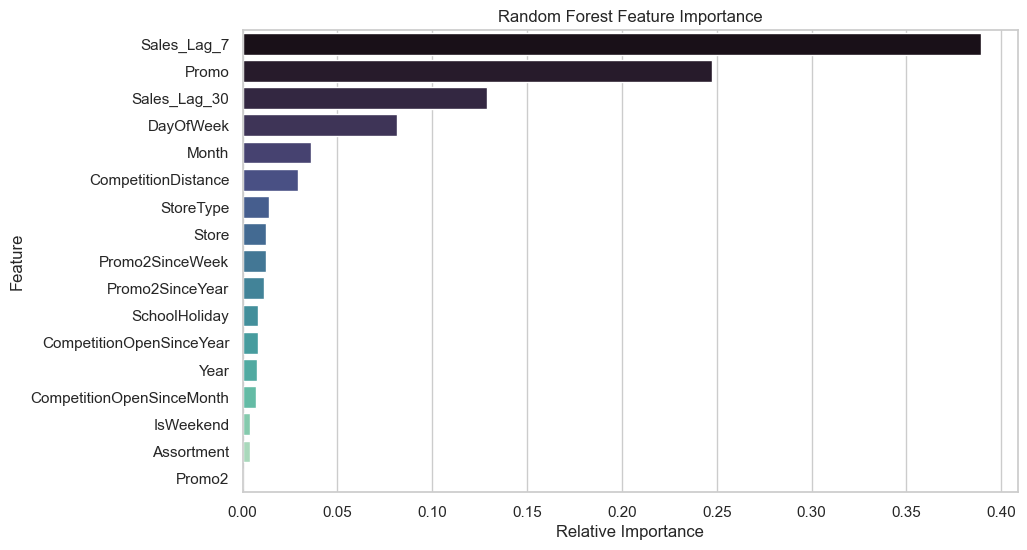


Exporting trained model...
Model successfully saved to: models/retail_rf_model.joblib
Note: Saved as .joblib (Scikit-Learn standard) fulfilling the model output requirement.


In [11]:
# 6. Feature Importance Interpretation & Model Export
def plot_feature_importance(model, feature_names):
    plt.figure(figsize=(10, 6))
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='mako')
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Relative Importance')
    plt.ylabel('Feature')
    plt.savefig('visualizations/9_feature_importance.png', bbox_inches='tight')
    plt.show()

def export_model(model, folder_path='models/'):
    print("\nExporting trained model...")
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        
    file_path = os.path.join(folder_path, 'retail_rf_model.joblib')
    joblib.dump(model, file_path)
    print(f"Model successfully saved to: {file_path}")
    print("Note: Saved as .joblib (Scikit-Learn standard) fulfilling the model output requirement.")

# Execute Interpretation
features = scaled_df.drop(columns=['Sales']).columns
plot_feature_importance(trained_rf_model, features)

# Execute Export
export_model(trained_rf_model)